# SCI++ (TPAMI) — Train · Fine-tune · Test · A/B (self-contained)

Everything in **one file**: model, loss, loader and metrics are **copied in as editable cells**
(no `import` from the project). Each operation is a **function you invoke with values** —
`train(...)`, `finetune(...)`, `run_test(...)`, `ab_test(...)`.

* **Best-model tracking:** after each epoch the model is scored by mean structure F1 of
  precision/recall (no ground-truth); the best epoch is saved as `*_best.pt`.
* **All models + graphs are saved under `./Experiment/`.**
* **Device-agnostic:** GPU when available, else CPU.

> Run from the `TPAMI/` folder.

## 0. Environment & imports
The OpenMP guard must run **before** `import torch` (harmless on GPU; avoids a Windows+Anaconda
duplicate-OpenMP kernel crash).

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')  # reduce GPU fragmentation

import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device, '| cuda available:', torch.cuda.is_available(), '| torch', torch.__version__)

device = cuda | cuda available: True | torch 2.7.1+cu128


## Loss — copied from `loss.py` (edit here to experiment)

In [2]:
import torch
import torch.nn as nn

class LossFunction(nn.Module):
    def __init__(self, noise_weight=0.0):
        super(LossFunction, self).__init__()
        self.l2_loss = nn.MSELoss()
        self.smooth_loss = SmoothLoss()
        # Weight on the reflectance-noise term. 0.0 -> original SCI++ objective.
        self.noise_weight = noise_weight

    def forward(self, input, illu, reflect=None):
        Fidelity_Loss = self.l2_loss(illu, input)
        Smooth_Loss = self.smooth_loss(input, illu)
        loss = 1.5 * Fidelity_Loss + Smooth_Loss

        # Deeper noise fix: the enhanced image r = input / illu amplifies sensor
        # noise where illu is small, and the original objective never constrains
        # r. Adding an input-guided edge-aware TV on r teaches the enhancer to
        # produce illumination whose division yields a cleaner reflectance --
        # gradients of r are penalised only where the input is flat (weights are
        # ~1 there, ~0 on real edges), so genuine structure is preserved.
        if reflect is not None and self.noise_weight > 0:
            loss = loss + self.noise_weight * self.smooth_loss(input, reflect)
        return loss



class SmoothLoss(nn.Module):
    def __init__(self):
        super(SmoothLoss, self).__init__()
        self.sigma = 10

    def rgb2yCbCr(self, input_im):
        im_flat = input_im.contiguous().view(-1, 3).float()
        mat = torch.tensor([[0.257, -0.148, 0.439], [0.564, -0.291, -0.368], [0.098, 0.439, -0.071]],
                           device=im_flat.device, dtype=im_flat.dtype)
        bias = torch.tensor([16.0 / 255.0, 128.0 / 255.0, 128.0 / 255.0],
                            device=im_flat.device, dtype=im_flat.dtype)
        temp = im_flat.mm(mat) + bias
        out = temp.view(input_im.shape[0], 3, input_im.shape[2], input_im.shape[3])
        return out

    # The 12 unique neighbour offsets (dy, dx) within the 5x5 window used by SCI.
    # The original code spelled out 24 directions, but every (dy,dx) and its
    # reverse (-dy,-dx) give identical squared-difference weights and L1 output
    # gradients (negating a difference changes nothing under square / abs), so we
    # evaluate each offset once and count it twice via the `* 2` in forward().
    _OFFSETS = [(1, 0), (0, 1), (1, 1), (1, -1),
                (2, 0), (0, 2), (2, 1), (2, -1),
                (1, 2), (1, -2), (2, 2), (2, -2)]

    @staticmethod
    def _shift_pair(t, dy, dx):
        """Return the two overlapping views of `t` whose pixels are separated by
        the vector (dy, dx). Slicing matches the original per-direction pairs."""
        ya = slice(dy, None) if dy > 0 else slice(None)
        yb = slice(0, t.shape[2] - dy) if dy > 0 else slice(None)
        if dx > 0:
            xa, xb = slice(dx, None), slice(0, t.shape[3] - dx)
        elif dx < 0:
            xa, xb = slice(0, t.shape[3] + dx), slice(-dx, None)
        else:
            xa = xb = slice(None)
        return t[:, :, ya, xa], t[:, :, yb, xb]

    # output: output      input:input
    def forward(self, input, output):
        self.output = output
        self.input = self.rgb2yCbCr(input)
        sigma_color = -1.0 / (2 * self.sigma * self.sigma)

        total_term = 0.0
        for dy, dx in self._OFFSETS:
            ia, ib = self._shift_pair(self.input, dy, dx)
            oa, ob = self._shift_pair(self.output, dy, dx)
            # input-guided edge weight: ~1 in flat regions, ~0 across real edges
            w = torch.exp(torch.sum(torch.pow(ia - ib, 2), dim=1, keepdim=True) * sigma_color)
            pixel_grad = w * torch.norm(oa - ob, 1, dim=1, keepdim=True)
            total_term = total_term + torch.mean(pixel_grad)

        # each offset stands in for itself and its reverse direction
        return 2.0 * total_term

## Model — copied from `model.py`
(`from loss import LossFunction` removed — `LossFunction` comes from the cell above)

In [3]:
import torch
import torch.nn as nn

import torch.nn.functional as F


def default_conv(dim_in, dim_out, kernel_size=3, bias=False):
    return nn.Conv2d(dim_in, dim_out, kernel_size, padding=(kernel_size//2), bias=bias)


def _luminance(x):
    """Rec.601 luma of an RGB tensor, kept as a 1-channel map."""
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


class GuidedFilter(nn.Module):
    """Edge-preserving smoothing (He et al. 2010), no learnable parameters.

    Why: SCI produces the enhanced image by Retinex division r = input / illu.
    Where illu is small (dark regions) this multiplies sensor noise by a large
    factor, and the training loss only smooths illu -- never r -- so the noise
    survives into the output. A guided filter removes it in flat areas while
    preserving edges, and runs in O(N) via box filters. Guiding it with the
    luminance concentrates smoothing where noise actually lives.
    """

    def __init__(self, radius=4, eps=1e-3):
        super().__init__()
        self.radius = radius
        self.eps = eps

    def _box(self, x):
        r = self.radius
        x = F.pad(x, (r, r, r, r), mode='replicate')
        return F.avg_pool2d(x, kernel_size=2 * r + 1, stride=1, padding=0)

    def forward(self, p, guide=None):
        I = p if guide is None else guide.expand_as(p)
        mean_I = self._box(I)
        mean_p = self._box(p)
        mean_Ip = self._box(I * p)
        cov_Ip = mean_Ip - mean_I * mean_p
        mean_II = self._box(I * I)
        var_I = mean_II - mean_I * mean_I
        a = cov_Ip / (var_I + self.eps)
        b = mean_p - a * mean_I
        return self._box(a) * I + self._box(b)


def soft_highlight(r, knee=0.9):
    """Smoothly roll off values above `knee` into [knee, 1) instead of hard
    clipping them. Recovers blown-out highlight detail that input/illu pushes
    past 1, while leaving mid-tones (r <= knee) untouched."""
    over = (r - knee).clamp(min=0)
    rolled = knee + (1 - knee) * (1 - torch.exp(-over / (1 - knee)))
    return torch.where(r > knee, rolled, r)


def unsharp(r, radius=2, amount=0.5):
    """Light unsharp mask on luminance only. Denoising + the tiny enhancer make
    output a bit flat; adding back high-frequency luma (not chroma) restores
    perceived clarity without re-amplifying colour noise."""
    y = _luminance(r)
    pad = F.pad(y, (radius, radius, radius, radius), mode='replicate')
    blur = F.avg_pool2d(pad, kernel_size=2 * radius + 1, stride=1, padding=0)
    detail = y - blur
    return (r + amount * detail).clamp(0, 1)


@torch.no_grad()
def edge_precision_recall(reference, enhanced, thresh=0.06, eps=1e-6):
    """Structure-preservation precision/recall for low-light enhancement.

    Uses the (low-light) input as the reference for *where real edges are* -- no
    ground-truth needed, so it works inside SCI++'s unsupervised training loop.
      recall    = fraction of reference edges retained in the output (structure kept)
      precision = fraction of output edges that are real, i.e. not spurious edges
                  hallucinated from amplified sensor noise
    Both in [0, 1]; higher is better. Returns (precision, recall) as Python floats.
    """
    def edge_map(x):
        y = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        gx = F.pad(y[:, :, :, 1:] - y[:, :, :, :-1], (0, 1, 0, 0))
        gy = F.pad(y[:, :, 1:, :] - y[:, :, :-1, :], (0, 0, 0, 1))
        mag = torch.sqrt(gx * gx + gy * gy + eps)
        return (mag > thresh).float()

    ref_e, out_e = edge_map(reference), edge_map(enhanced)
    tp = (ref_e * out_e).sum()
    precision = (tp / (out_e.sum() + eps)).item()
    recall = (tp / (ref_e.sum() + eps)).item()
    return precision, recall


class EnhanceNetwork_Ha(nn.Module):
    def __init__(self, layers, channels):
        super(EnhanceNetwork_Ha, self).__init__()

        kernel_size = 3
        self.in_conv = nn.Sequential(
            default_conv(dim_in=3, dim_out=channels, kernel_size=kernel_size, bias=True),
            nn.ReLU()
        )

        self.blocks = nn.ModuleList()
        for _ in range(layers):
            conv = nn.Sequential(
                default_conv(dim_in=channels, dim_out=channels, kernel_size=kernel_size, bias=True),
                nn.ReLU()
            )
            self.blocks.append(conv)

        self.out_conv = nn.Sequential(
            default_conv(dim_in=channels, dim_out=3, kernel_size=kernel_size, bias=True),
            nn.Sigmoid()
        )

    def forward(self, input):
        fea = self.in_conv(input)
        for conv in self.blocks:
            fea = fea + conv(fea)
        fea = self.out_conv(fea)

        illu = fea + input
        illu = torch.clamp(illu, 0.0001, 1)

        return illu



class EnhanceNetwork_Hb(nn.Module):
    def __init__(self, layers, channels):
        super(EnhanceNetwork_Hb, self).__init__()
        kernel_size = 3
        self.in_conv = nn.Sequential(
            default_conv(dim_in=3, dim_out=channels, kernel_size=kernel_size, bias=True),
            nn.ReLU()
        )

        self.blocks = nn.ModuleList()
        for _ in range(layers):
            conv = nn.Sequential(
                default_conv(dim_in=channels, dim_out=channels, kernel_size=kernel_size, bias=True),
                nn.ReLU()
            )
            self.blocks.append(conv)

        self.out_conv = nn.Sequential(
            default_conv(dim_in=channels, dim_out=3, kernel_size=kernel_size, bias=True),
        )

    def forward(self, input):
        fea = self.in_conv(input)
        for conv in self.blocks:
            fea = fea + conv(fea)
        fea = self.out_conv(fea)
        return fea


class CalibrateNetwork(nn.Module):
    def __init__(self, layers, channels):
        super(CalibrateNetwork, self).__init__()
        kernel_size = 3
        dilation = 1
        padding = int((kernel_size - 1) / 2) * dilation
        self.layers = layers

        self.in_conv = nn.Sequential(
            default_conv(dim_in=3, dim_out=channels, kernel_size=kernel_size, bias=True),
            nn.ReLU()
        )

        self.blocks = nn.ModuleList()
        for _ in range(layers):
            convs = nn.Sequential(
                default_conv(dim_in=channels, dim_out=channels, kernel_size=kernel_size, bias=True),                nn.ReLU(),
                default_conv(dim_in=channels, dim_out=channels, kernel_size=kernel_size, bias=True),                nn.ReLU()
            )
            self.blocks.append(convs)

        self.out_conv = nn.Sequential(
            default_conv(dim_in=channels, dim_out=3, kernel_size=kernel_size, bias=True),
        )

    def forward(self, input):
        fea = self.in_conv(input)
        for conv in self.blocks:
            fea = fea + conv(fea)

        fea = self.out_conv(fea)
        delta = input + fea

        return delta



class Network(nn.Module):

    def __init__(self, stage=3, noise_weight=0.0):
        super(Network, self).__init__()
        self.stage = stage
        self.ha = EnhanceNetwork_Ha(layers=1, channels=3)
        self.hb = EnhanceNetwork_Hb(layers=3, channels=16)
        self.calibrate = CalibrateNetwork(layers=3, channels=16)
        self._criterion = LossFunction(noise_weight=noise_weight)

    def weights_init(self, m):
        if isinstance(m, nn.Conv2d):
            m.weight.data.normal_(0, 0.02)
            m.bias.data.zero_()

        if isinstance(m, nn.BatchNorm2d):
            m.weight.data.normal_(1., 0.02)

    def forward(self, input):

        ilist, rlist, inlist, attlist = [], [], [], []
        input_op = input

        i = self.ha(input_op)
        r = input / i
        r = torch.clamp(r, 0, 1)
        ilist.append(i)
        rlist.append(r)
        inlist.append(input_op)

        for _ in range(1, self.stage):
            inlist.append(i)
            att = self.calibrate(r)
            att_1 = self.hb(att)

            i = i + att + att_1
            r = input / i
            r = torch.clamp(r, 0, 1)

            ilist.append(i)
            rlist.append(r)
            attlist.append(torch.abs(att))

        return ilist, rlist, inlist, attlist

    def _loss_Jiaoti(self, input):
        i_list, en_list, in_list, _ = self(input)

        # en_list[k] is the reflectance r at stage k; pass it so the criterion
        # can apply the reflectance-noise penalty (no-op when noise_weight == 0).
        # Note: in loss2/loss3 the criterion is scaled by 0.1, so the noise term
        # inherits that 0.1 weight on the later stages while loss1 gets it fully.
        loss1 = self._criterion(in_list[0], i_list[0], reflect=en_list[0])
        loss2 = F.l1_loss(i_list[0], i_list[1]) + 0.1*self._criterion(in_list[0], i_list[1], reflect=en_list[1])
        loss3 = F.l1_loss(i_list[0], i_list[2]) + 0.1*self._criterion(in_list[0], i_list[2], reflect=en_list[2])
        return en_list, loss1, loss2, loss3


class Finetunemodel(nn.Module):

    def __init__(self, weights, denoise=False, denoise_radius=4, denoise_eps=1e-3,
                 gamma=1.0, highlight=False, sharpen=0.0, noise_weight=0.0):
        super(Finetunemodel, self).__init__()
        self.ha = EnhanceNetwork_Ha(layers=1, channels=3)
        self._criterion = LossFunction(noise_weight=noise_weight)

        # Inference-time refinements (all no-ops at their defaults, so the model
        # reproduces the original SCI++ output unless explicitly enabled).
        self.gamma = gamma            # <1 tempers gain in darkest pixels -> less noise
        self.highlight = highlight    # soft-clip blown highlights instead of hard clamp
        self.sharpen = sharpen        # unsharp amount on luminance for clarity
        self.guided = GuidedFilter(denoise_radius, denoise_eps) if denoise else None

        base_weights = torch.load(weights, map_location='cpu')
        pretrained_dict = base_weights
        model_dict = self.state_dict()
        pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict}
        model_dict.update(pretrained_dict)
        self.load_state_dict(model_dict)

    def weights_init(self, m):
        if isinstance(m, nn.Conv2d):
            m.weight.data.normal_(0, 0.02)
            m.bias.data.zero_()

        if isinstance(m, nn.BatchNorm2d):
            m.weight.data.normal_(1., 0.02)

    def forward(self, input):
        i = self.ha(input)

        # gamma < 1 raises the illumination toward 1 in the darkest pixels, so
        # the division brightens (and amplifies noise) less aggressively there.
        illu = torch.clamp(i ** self.gamma, 0.0001, 1) if self.gamma != 1.0 else i
        r = input / illu

        # Edge-preserving denoise, guided by luminance (noise is worst where dark).
        if self.guided is not None:
            r = self.guided(r, guide=_luminance(r))

        # Highlights: soft rolloff to recover detail, else the original hard clip.
        r = soft_highlight(r) if self.highlight else torch.clamp(r, 0, 1)

        # Optional clarity pass on luminance.
        if self.sharpen > 0:
            r = unsharp(r, amount=self.sharpen)

        r = torch.clamp(r, 0, 1)
        return i, r


    def _loss(self, input):
        i = self.ha(input)
        # Raw reflectance (no inference-time refinement) so the noise penalty
        # trains on the true division output regardless of denoise/gamma flags.
        r = torch.clamp(input / i, 0, 1)
        loss = self._criterion(input, i, reflect=r)
        return loss

## Dataset loader — copied from `multi_read_data.py`

In [4]:
import numpy as np
import torch
import torch.utils.data
import random
from PIL import Image
from glob import glob
import torchvision.transforms as transforms
import os

batch_w = 600
batch_h = 400


class MemoryFriendlyLoader(torch.utils.data.Dataset):
    def __init__(self, img_dir, task):
        self.low_img_dir = img_dir
        self.task = task
        self.train_low_data_names = []

        for root, dirs, names in os.walk(self.low_img_dir):
            for name in names:
                self.train_low_data_names.append(os.path.join(root, name))

        self.train_low_data_names.sort()
        self.count = len(self.train_low_data_names)

        transform_list = []
        transform_list += [transforms.ToTensor()]
        self.transform = transforms.Compose(transform_list)

    def load_images_transform(self, file):
        im = Image.open(file).convert('RGB')
        img_norm = self.transform(im).numpy()
        img_norm = np.transpose(img_norm, (1, 2, 0))
        return img_norm

    def __getitem__(self, index):

        low = self.load_images_transform(self.train_low_data_names[index])

        h = low.shape[0]
        w = low.shape[1]
        #
        h_offset = random.randint(0, max(0, h - batch_h - 1))
        w_offset = random.randint(0, max(0, w - batch_w - 1))
        #
        # if self.task != 'test':
        #     low = low[h_offset:h_offset + batch_h, w_offset:w_offset + batch_w]

        low = np.asarray(low, dtype=np.float32)
        low = np.transpose(low[:, :, :], (2, 0, 1))

        img_name = self.train_low_data_names[index].split('\\')[-1]
        # if self.task == 'test':
        #     # img_name = self.train_low_data_names[index].split('\\')[-1]
        #     return torch.from_numpy(low), img_name

        return torch.from_numpy(low), img_name

    def __len__(self):
        return self.count

## Metric helpers — copied from `compare_eval.py` (noise / PSNR / SSIM)

In [5]:
from numpy.lib.stride_tricks import sliding_window_view

def _luma(img):  # HxWx3 [0,1] -> HxW
    return 0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]


def noise_sigma(img):
    """Immerkaer no-reference noise estimate on luminance, scaled to 0..255."""
    y = _luma(img)
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float32)
    w = sliding_window_view(y, (3, 3))
    return float(np.abs((w * M).sum(axis=(-1, -2))).mean() * np.sqrt(0.5 * np.pi) / 6.0) * 255


def psnr(a, b):
    mse = float(np.mean((a - b) ** 2))
    return 99.0 if mse == 0 else float(10 * np.log10(1.0 / mse))


def _gaussian(size=11, sigma=1.5):
    ax = np.arange(size) - size // 2
    g = np.exp(-(ax ** 2) / (2 * sigma ** 2))
    g = np.outer(g, g)
    return g / g.sum()


def ssim(a, b):
    """Grayscale gaussian-windowed SSIM on luminance."""
    a, b = _luma(a), _luma(b)
    win = _gaussian()
    k = win.shape[0]
    pa = np.pad(a, k // 2, mode='reflect')
    pb = np.pad(b, k // 2, mode='reflect')
    wa = sliding_window_view(pa, (k, k))
    wb = sliding_window_view(pb, (k, k))
    mu_a = (wa * win).sum((-1, -2))
    mu_b = (wb * win).sum((-1, -2))
    va = (wa ** 2 * win).sum((-1, -2)) - mu_a ** 2
    vb = (wb ** 2 * win).sum((-1, -2)) - mu_b ** 2
    cov = (wa * wb * win).sum((-1, -2)) - mu_a * mu_b
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    s = ((2 * mu_a * mu_b + c1) * (2 * cov + c2)) / ((mu_a ** 2 + mu_b ** 2 + c1) * (va + vb + c2))
    return float(s.mean())

## Config — defaults for the functions below
These are default argument values; every function accepts overrides per call. All produced
models and selection graphs are written under **`EXP_DIR`** (`./Experiment`).

In [6]:
# ----- paths -----
EXP_DIR    = './Experiment'                  # all our models + graphs go here
DATA       = './data'
FT_DATA    = './data_finetune'               # fine-tune scenes (kept OUTSIDE ./data)
BASE_W     = './weights/weights_1_3500.pt'   # pretrained baseline (input, not our output)
NB_TRAIN_W = os.path.join(EXP_DIR, 'nb_trained.pt')
NB_FT_W    = os.path.join(EXP_DIR, 'nb_finetuned.pt')
TEST_OUT   = './results/nb_test'
AB_OUT     = './results/nb_ab'

# ----- defaults -----
STAGE        = 3
LR           = 3e-4
NOISE_WEIGHT = 0.1
EPOCHS_TRAIN = 3
FT_STEPS     = 3
PATCH        = 256      # LOW-GPU-MEMORY: train/val crop size (None = full image; #1 memory lever)
AMP          = True     # mixed precision on CUDA (auto-disabled on CPU; ~2x less memory)
DENOISE, DENOISE_RADIUS, DENOISE_EPS = True, 4, 1e-3
GAMMA, HIGHLIGHT, SHARPEN = 0.8, True, 0.5

# fall back to DATA if the dedicated fine-tune set is missing/empty
if not (os.path.isdir(FT_DATA) and os.listdir(FT_DATA)):
    print('FT_DATA empty -> using DATA for fine-tune'); FT_DATA = DATA

PIN = (device.type == 'cuda')
def make_loader(path, task, shuffle=False):
    return torch.utils.data.DataLoader(MemoryFriendlyLoader(path, task), batch_size=1,
                                       shuffle=shuffle, num_workers=0, pin_memory=PIN)
def to_np(t):
    return np.transpose(t[0].detach().cpu().float().numpy(), (1, 2, 0))
def save_img(arr, path):
    Image.fromarray(np.clip(arr * 255.0, 0, 255).astype('uint8')).save(path, 'png')

def random_crop(x, size):
    _, _, h, w = x.shape
    if not size or (h <= size and w <= size): return x
    th, tw = min(size, h), min(size, w)
    i = int(torch.randint(0, h - th + 1, (1,)).item()); j = int(torch.randint(0, w - tw + 1, (1,)).item())
    return x[:, :, i:i+th, j:j+tw]
def center_crop(x, size):
    _, _, h, w = x.shape
    if not size or (h <= size and w <= size): return x
    th, tw = min(size, h), min(size, w)
    i, j = (h - th) // 2, (w - tw) // 2
    return x[:, :, i:i+th, j:j+tw]

def _mean_structure_f1(enhance_fn, val_data, crop=None):
    """Mean F1 of (precision, recall) of enhanced-vs-input edges over val_data.
    `crop` center-crops inputs to cap validation memory (else val can OOM once train is cropped).
    No ground-truth needed."""
    f1s = []
    with torch.no_grad():
        for inp, _ in make_loader(val_data, 'test'):
            inp = inp.to(device)
            if crop: inp = center_crop(inp, crop)
            p, rc = edge_precision_recall(inp, enhance_fn(inp))
            f1s.append(2 * p * rc / (p + rc + 1e-8))
    return float(np.mean(f1s)) if f1s else 0.0

for d in (EXP_DIR, TEST_OUT, AB_OUT):
    os.makedirs(d, exist_ok=True)
print('config ready | models ->', EXP_DIR, '| PATCH', PATCH, '| AMP', AMP)

config ready | models -> ./Experiment | PATCH 256 | AMP True


## Pipeline functions — invoke these with your own values

Defaults come from Config; pass keyword args to override (e.g. `train(epochs=10, noise_weight=0.3)`).
`train` / `finetune` return `(model, history)`, where `history` is the per-epoch loss + validation
F1 used to pick the best checkpoint — feed it to `plot_selection(...)`.

In [7]:
def train(epochs=EPOCHS_TRAIN, lr=LR, stage=STAGE, noise_weight=NOISE_WEIGHT,
          data=DATA, val_data=DATA, out_weights=NB_TRAIN_W, best_weights=None,
          patch=PATCH, val_patch=None, amp=AMP, seed=2, save_every=500, ckpt_dir=None):
    """Low-GPU-memory training (equivalent of train.py) with BEST-MODEL TRACKING.

    The model is tiny, so ACTIVATIONS dominate GPU memory. Levers:
      * `patch` -> train on random patch x patch crops (None = full image). The #1 lever
        (~10-15x less activation memory); CPU-verifiable.
      * `amp`   -> mixed precision on CUDA (~2x less memory); auto-off on CPU.
      * validation is center-cropped to `val_patch` (defaults to `patch`) so eval doesn't
        become the new memory ceiling.
    Losses: like train.py, all three SCI++ losses (loss1, loss2, loss3) are computed every
    step; `total = loss1 + loss2 + loss3`. The optimised branch is loss1 (ha steps) or
    loss2+loss3 (hb/calibrate steps). Per-epoch means of all four go into `history`.
    Step checkpoints (like train.py): every `save_every` global steps the model is written
    to `ckpt_dir/weights_{epoch}_{step}.pt` (set `save_every=0` to disable). `ckpt_dir`
    defaults to `EXP_DIR/model_epochs`.
    BEST MODEL: the checkpoint with the highest validation structure-F1 is saved as `*_best.pt`.
    Saves latest + `*_best.pt` under EXP_DIR. Returns (model, history)."""
    best_weights = best_weights or out_weights.replace('.pt', '_best.pt')
    ckpt_dir = ckpt_dir or os.path.join(EXP_DIR, 'model_epochs')
    if save_every: os.makedirs(ckpt_dir, exist_ok=True)
    vp = val_patch if val_patch is not None else patch
    torch.manual_seed(seed); np.random.seed(seed)
    model = Network(stage=stage, noise_weight=noise_weight).to(device)
    opt_a = torch.optim.Adam(model.ha.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=3e-4)
    opt_b = torch.optim.Adam(list(model.hb.parameters()) + list(model.calibrate.parameters()),
                             lr=lr, betas=(0.9, 0.999), weight_decay=3e-4)
    use_amp = bool(amp) and device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    dl = make_loader(data, 'train')
    if device.type == 'cuda': torch.cuda.reset_peak_memory_stats()
    history, best, total_step = [], -1.0, 0
    for epoch in range(epochs):
        model.train(); losses, l1s, l2s, l3s, totals = [], [], [], [], []
        for inp, _ in dl:
            total_step += 1
            inp = inp.to(device, non_blocking=PIN)
            inp = random_crop(inp, patch)
            train_ha = (total_step % 10 < 7)
            for p in model.ha.parameters():        p.requires_grad = train_ha
            for p in model.hb.parameters():        p.requires_grad = not train_ha
            for p in model.calibrate.parameters(): p.requires_grad = not train_ha
            opt = opt_a if train_ha else opt_b
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                en_list, l1, l2, l3 = model._loss_Jiaoti(inp)
                loss = l1 if train_ha else (l2 + l3)
            pr, rc = edge_precision_recall(inp, en_list[-1])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            clip_params = (list(model.ha.parameters()) if train_ha
                           else list(model.hb.parameters()) + list(model.calibrate.parameters()))
            nn.utils.clip_grad_norm_(clip_params, 5)               # clip ACTIVE branch only
            scaler.step(opt); scaler.update()
            # record all three losses + their total every step (like train.py)
            v1, v2, v3 = l1.item(), l2.item(), l3.item()
            losses.append(loss.item()); l1s.append(v1); l2s.append(v2); l3s.append(v3)
            totals.append(v1 + v2 + v3)
            # step checkpoint, mirroring train.py's `if total_step % 500 == 0`
            if save_every and total_step % save_every == 0:
                ckpt = os.path.join(ckpt_dir, f'weights_{epoch}_{total_step}.pt')
                torch.save(model.state_dict(), ckpt)
                print(f'    [ckpt] step {total_step} -> {ckpt}')
        model.eval()
        val_f1 = _mean_structure_f1(lambda x: model(x)[1][-1], val_data, crop=vp)
        torch.save(model.state_dict(), out_weights)               # latest
        is_best = val_f1 > best
        if is_best:
            best = val_f1; torch.save(model.state_dict(), best_weights)   # BEST MODEL
        history.append(dict(epoch=epoch, loss=float(np.mean(losses)),
                            loss1=float(np.mean(l1s)), loss2=float(np.mean(l2s)),
                            loss3=float(np.mean(l3s)), total=float(np.mean(totals)),
                            val_f1=val_f1, is_best=is_best))
        print(f'  [train] EPOCH {epoch:03d} | Tloss {np.mean(losses):.4f} '
              f'| l1 {np.mean(l1s):.4f} l2 {np.mean(l2s):.4f} l3 {np.mean(l3s):.4f} '
              f'| total {np.mean(totals):.4f} | val F1 {val_f1:.3f}'
              + ('  <-- new best' if is_best else ''))
    if device.type == 'cuda':
        print(f'  peak GPU mem: {torch.cuda.max_memory_allocated() / 1e6:.0f} MB')
    print(f'  best val F1 = {best:.3f} -> {best_weights}   (latest -> {out_weights})')
    return model, history

In [8]:
def finetune(model_weights=BASE_W, noise_weight=NOISE_WEIGHT, steps=FT_STEPS, lr=5e-4,
             ft_data=FT_DATA, val_data=None, out_weights=NB_FT_W, best_weights=None,
             patch=PATCH, val_patch=None, amp=AMP):
    """Fine-tune the baseline (ha) with the reflectance-noise penalty (equivalent of finetune.py),
    BEST-MODEL TRACKING by structure F1, and the same low-GPU-memory levers as train()
    (`patch` crop + `amp`). Saves under EXP_DIR. Returns (model, history)."""
    val_data = val_data or ft_data
    vp = val_patch if val_patch is not None else patch
    best_weights = best_weights or out_weights.replace('.pt', '_best.pt')
    ft = Finetunemodel(model_weights, noise_weight=noise_weight).to(device)
    opt = torch.optim.Adam(ft.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=3e-4)
    use_amp = bool(amp) and device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    dl = make_loader(ft_data, 'train', shuffle=True)
    if device.type == 'cuda': torch.cuda.reset_peak_memory_stats()
    history, best = [], -1.0
    for step in range(steps):
        ft.train(); L, P, R = [], [], []
        for inp, _ in dl:
            inp = inp.to(device, non_blocking=PIN)
            inp = random_crop(inp, patch)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                loss = ft._loss(inp)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(ft.parameters(), 5)
            scaler.step(opt); scaler.update()
            with torch.no_grad():
                _, r = ft(inp)
            pr, rc = edge_precision_recall(inp, r)
            L.append(loss.item()); P.append(pr); R.append(rc)
        ft.eval()
        val_f1 = _mean_structure_f1(lambda x: ft(x)[1], val_data, crop=vp)
        torch.save(ft.state_dict(), out_weights)
        is_best = val_f1 > best
        if is_best:
            best = val_f1; torch.save(ft.state_dict(), best_weights)
        history.append(dict(epoch=step, loss=float(np.mean(L)), val_f1=val_f1, is_best=is_best))
        print(f'  [finetune] EPOCH {step:03d} | loss {np.mean(L):.4f} '
              f'| val F1 {val_f1:.3f}' + ('  <-- new best' if is_best else ''))
    if device.type == 'cuda':
        print(f'  peak GPU mem: {torch.cuda.max_memory_allocated() / 1e6:.0f} MB')
    print(f'  best val F1 = {best:.3f} -> {best_weights}   (latest -> {out_weights})')
    return ft, history

In [9]:
def plot_selection(history, title='', save_dir=EXP_DIR):
    """Visualise WHY a checkpoint was chosen as best: plot validation structure-F1 per epoch
    (the selection metric) with the chosen epoch starred, and the training loss on a twin axis
    to show F1 — not loss — drives the choice. Saves the figure under EXP_DIR."""
    ep   = [h['epoch']  for h in history]
    f1   = [h['val_f1'] for h in history]
    loss = [h['loss']   for h in history]
    best_i = int(np.argmax(f1))

    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.plot(ep, f1, '-o', color='#2a9d8f', lw=2, label='val structure F1 (selection metric)')
    ax.axvline(ep[best_i], ls='--', color='#e76f51', alpha=.6)
    ax.scatter([ep[best_i]], [f1[best_i]], s=240, marker='*', color='#e76f51', zorder=5,
               label=f'chosen best: epoch {ep[best_i]} (F1={f1[best_i]:.3f})')
    ax.annotate('saved as *_best.pt\n(highest val F1)', (ep[best_i], f1[best_i]),
                textcoords='offset points', xytext=(10, -28), color='#e76f51', fontsize=9)
    ax.set_xlabel('epoch'); ax.set_ylabel('val structure F1 (higher = better)', color='#2a9d8f')
    ax.set_xticks(ep)

    ax2 = ax.twinx()
    ax2.plot(ep, loss, ':', color='#888', lw=1.6, label='train loss')
    ax2.set_ylabel('train loss', color='#888')

    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best', fontsize=9)
    ax.set_title(f'{title}: best-model selection — keep the epoch with peak val F1', fontweight='bold')
    fig.tight_layout()
    out = os.path.join(save_dir, f'{title.lower().replace(" ", "_") or "run"}_best_selection.png')
    fig.savefig(out, dpi=110); plt.show()
    print('saved selection graph ->', out)

In [10]:
def run_test(weights=NB_FT_W, data=DATA, out_dir=TEST_OUT, denoise=DENOISE,
             denoise_radius=DENOISE_RADIUS, denoise_eps=DENOISE_EPS, gamma=GAMMA,
             highlight=HIGHLIGHT, sharpen=SHARPEN, show=3):
    """Enhance every image in `data` (equivalent of test.py); save to out_dir, preview a few.
    Pass a *_best.pt path to test the best checkpoint. Returns the output filenames."""
    os.makedirs(out_dir, exist_ok=True)
    model = Finetunemodel(weights, denoise=denoise, denoise_radius=denoise_radius,
                          denoise_eps=denoise_eps, gamma=gamma, highlight=highlight,
                          sharpen=sharpen).to(device).eval()
    saved = []
    with torch.no_grad():
        for inp, name in make_loader(data, 'test'):
            inp = inp.to(device)
            stem = os.path.splitext(os.path.basename(name[0]))[0]
            _, r = model(inp)
            save_img(to_np(r), os.path.join(out_dir, stem + '.png'))
            saved.append(stem + '.png')
    print(f'  wrote {len(saved)} images -> {out_dir}')
    sh = saved[:show]
    if sh:
        fig, axes = plt.subplots(1, len(sh), figsize=(5*len(sh), 4)); axes = np.atleast_1d(axes)
        for ax, f in zip(axes, sh):
            ax.imshow(np.asarray(Image.open(os.path.join(out_dir, f)))); ax.set_title(f, fontsize=9); ax.axis('off')
        fig.suptitle('Enhanced outputs', fontweight='bold'); fig.tight_layout(); plt.show()
    return saved

In [11]:
def ab_test(baseline_weights=BASE_W, modified_weights=NB_FT_W, data=DATA, out_dir=AB_OUT,
            denoise=DENOISE, denoise_radius=DENOISE_RADIUS, denoise_eps=DENOISE_EPS,
            gamma=GAMMA, highlight=HIGHLIGHT, sharpen=SHARPEN):
    """A/B compare baseline vs modified (equivalent of compare_eval.py). Writes 3-panel
    [actual | baseline | fine-tuned] strips + a full-name metrics CSV. Returns the DataFrame."""
    os.makedirs(out_dir, exist_ok=True)
    base_m = Finetunemodel(baseline_weights).to(device).eval()
    mod_m  = Finetunemodel(modified_weights, denoise=denoise, denoise_radius=denoise_radius,
                           denoise_eps=denoise_eps, gamma=gamma, highlight=highlight,
                           sharpen=sharpen).to(device).eval()
    rows = []
    with torch.no_grad():
        for inp, name in make_loader(data, 'test'):
            inp = inp.to(device)
            full = os.path.basename(name[0]); stem = os.path.splitext(full)[0]
            actual = to_np(inp)
            base = to_np(torch.clamp(inp / base_m.ha(inp), 0, 1))
            _, mt = mod_m(inp); mod = to_np(mt)
            h = min(p.shape[0] for p in (actual, base, mod)); w = min(p.shape[1] for p in (actual, base, mod))
            save_img(np.concatenate([actual[:h, :w], base[:h, :w], mod[:h, :w]], axis=1),
                     os.path.join(out_dir, stem + '.png'))
            rows.append(dict(image=full,
                             noise_base=round(noise_sigma(base), 3), noise_mod=round(noise_sigma(mod), 3),
                             bright_base=round(float(_luma(base).mean()), 3), bright_mod=round(float(_luma(mod).mean()), 3),
                             contrast_base=round(float(_luma(base).std()), 3), contrast_mod=round(float(_luma(mod).std()), 3),
                             psnr_impact=round(psnr(base, mod), 2), ssim_impact=round(ssim(base, mod), 4)))
    df = pd.DataFrame(rows); df.to_csv(os.path.join(out_dir, 'metrics.csv'), index=False)
    print(f'  wrote {len(df)} strips + metrics.csv -> {out_dir}')
    return df

def show_ab(df, out_dir=AB_OUT):
    """Render the A/B averages chart + a few [actual | baseline | fine-tuned] strips."""
    avg = df.drop(columns=['image']).mean(numeric_only=True).round(3)
    labels = ['noise', 'bright', 'contrast']
    bv = [avg[f'{m}_base'] for m in labels]; mv = [avg[f'{m}_mod'] for m in labels]
    x = np.arange(len(labels)); w = 0.38
    fig, ax = plt.subplots(figsize=(7, 4))
    b1 = ax.bar(x - w/2, bv, w, label='A: baseline', color='#888')
    b2 = ax.bar(x + w/2, mv, w, label='B: modified', color='#2a9d8f')
    ax.bar_label(b1, fmt='%.3f', fontsize=8); ax.bar_label(b2, fmt='%.3f', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(['noise', 'brightness', 'contrast'])
    ax.set_title('Average metrics: A vs B', fontweight='bold'); ax.legend(); fig.tight_layout(); plt.show()
    strips = sorted(f for f in os.listdir(out_dir) if f.endswith('.png'))[:3]
    fig, axes = plt.subplots(len(strips), 1, figsize=(13, 3.2*len(strips))); axes = np.atleast_1d(axes)
    for ax, f in zip(axes, strips):
        ax.imshow(np.asarray(Image.open(os.path.join(out_dir, f))))
        ax.set_title(f'{f}   [ actual | baseline | fine-tuned ]', fontsize=9); ax.axis('off')
    fig.tight_layout(); plt.show()

## 1. Invoke — train  (saves latest + best under ./Experiment, then graphs the selection)

c:\Users\Samarpan\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1341: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


    [ckpt] step 500 -> ./Experiment\model_epochs\weights_0_500.pt
    [ckpt] step 1000 -> ./Experiment\model_epochs\weights_0_1000.pt
    [ckpt] step 1500 -> ./Experiment\model_epochs\weights_0_1500.pt
    [ckpt] step 2000 -> ./Experiment\model_epochs\weights_0_2000.pt
  [train] EPOCH 000 | Tloss nan | l1 1.3660 l2 0.2007 l3 nan | total nan | val F1 0.984  <-- new best
    [ckpt] step 2500 -> ./Experiment\model_epochs\weights_1_2500.pt
    [ckpt] step 3000 -> ./Experiment\model_epochs\weights_1_3000.pt
    [ckpt] step 3500 -> ./Experiment\model_epochs\weights_1_3500.pt
    [ckpt] step 4000 -> ./Experiment\model_epochs\weights_1_4000.pt
  [train] EPOCH 001 | Tloss 0.7377 | l1 0.9553 l2 0.1102 l3 0.1220 | total 1.1875 | val F1 0.990  <-- new best
    [ckpt] step 4500 -> ./Experiment\model_epochs\weights_2_4500.pt
    [ckpt] step 5000 -> ./Experiment\model_epochs\weights_2_5000.pt
    [ckpt] step 5500 -> ./Experiment\model_epochs\weights_2_5500.pt
    [ckpt] step 6000 -> ./Experiment\mode

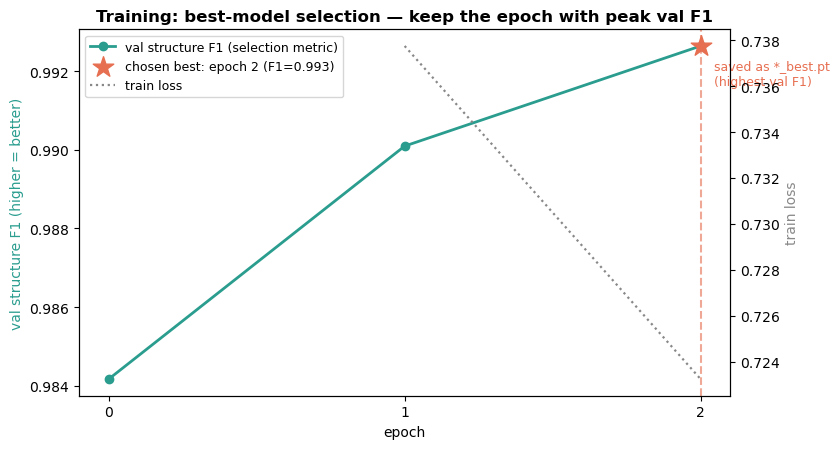

saved selection graph -> ./Experiment\training_best_selection.png


In [12]:
model, train_hist = train(epochs=EPOCHS_TRAIN, patch=PATCH, amp=AMP)
plot_selection(train_hist, 'Training')

## 2. Invoke — fine-tune

  [finetune] EPOCH 000 | loss 0.9193 | val F1 0.304  <-- new best
  [finetune] EPOCH 001 | loss 0.8151 | val F1 0.310  <-- new best
  [finetune] EPOCH 002 | loss 0.8385 | val F1 0.315  <-- new best
  peak GPU mem: 138 MB
  best val F1 = 0.315 -> ./Experiment\nb_finetuned_best.pt   (latest -> ./Experiment\nb_finetuned.pt)


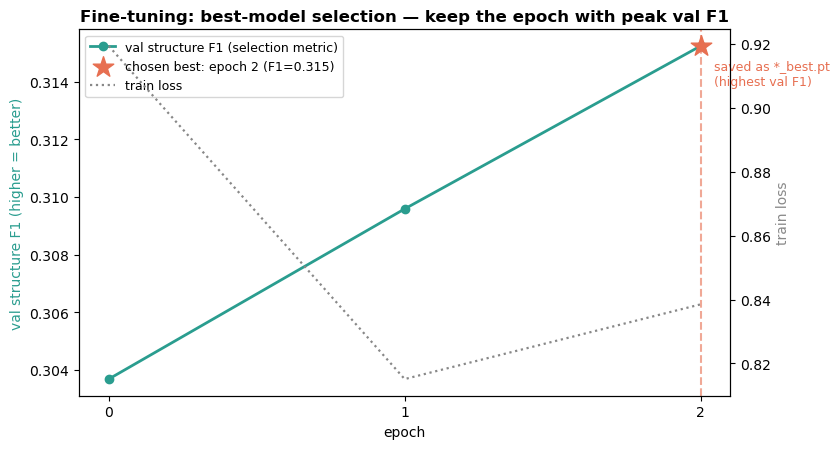

saved selection graph -> ./Experiment\fine-tuning_best_selection.png


In [ ]:
ft, ft_hist = finetune(steps=FT_STEPS,  amp=AMP)
plot_selection(ft_hist, 'Fine-tuning')

## 3. Invoke — test  (use the BEST fine-tuned checkpoint)

  wrote 10 images -> ./results/nb_test


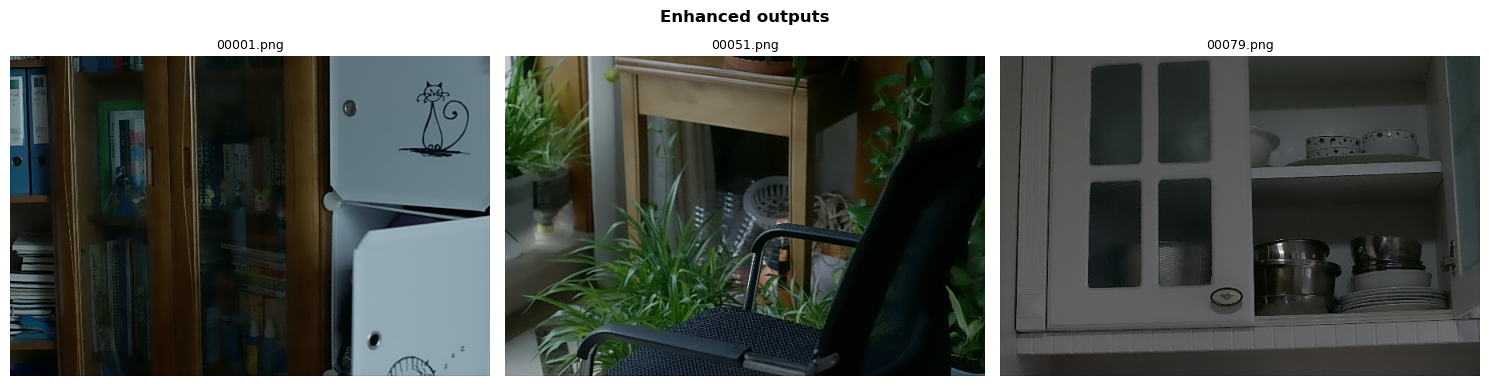

In [17]:
saved = run_test(weights=NB_FT_W.replace('.pt', '_best.pt'), gamma=GAMMA, denoise=DENOISE, highlight=HIGHLIGHT, sharpen=SHARPEN, data=FT_DATA)

## 4. Invoke — A/B testing  (baseline vs best fine-tuned)

  wrote 10 strips + metrics.csv -> ./results/nb_ab


,image,noise_base,noise_mod,bright_base,bright_mod,contrast_base,contrast_mod,psnr_impact,ssim_impact
0,00001.png,3.700,1.756,0.356,0.247,0.283,0.209,17.40,0.8312
1,00051.png,5.002,3.224,0.292,0.195,0.214,0.150,18.56,0.8443
2,00079.png,4.259,1.763,0.373,0.245,0.155,0.105,17.23,0.8006
3,00091.png,3.535,1.243,0.454,0.303,0.191,0.131,15.82,0.8148
4,2062.jpg,2.066,1.691,0.644,0.473,0.235,0.220,14.91,0.8799
5,2064.jpg,2.773,1.906,0.349,0.243,0.242,0.203,18.41,0.8223
6,3008.jpg,4.752,5.237,0.579,0.410,0.270,0.219,14.81,0.8716
7,3018.jpg,2.001,1.172,0.450,0.312,0.267,0.201,16.27,0.8418
8,3020.jpg,1.521,0.786,0.427,0.311,0.280,0.249,17.68,0.8455
9,NPE_71.png,1.667,1.133,0.524,0.370,0.226,0.195,16.00,0.8562


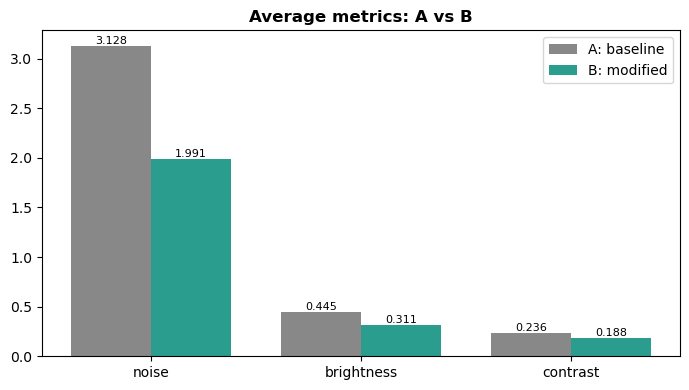

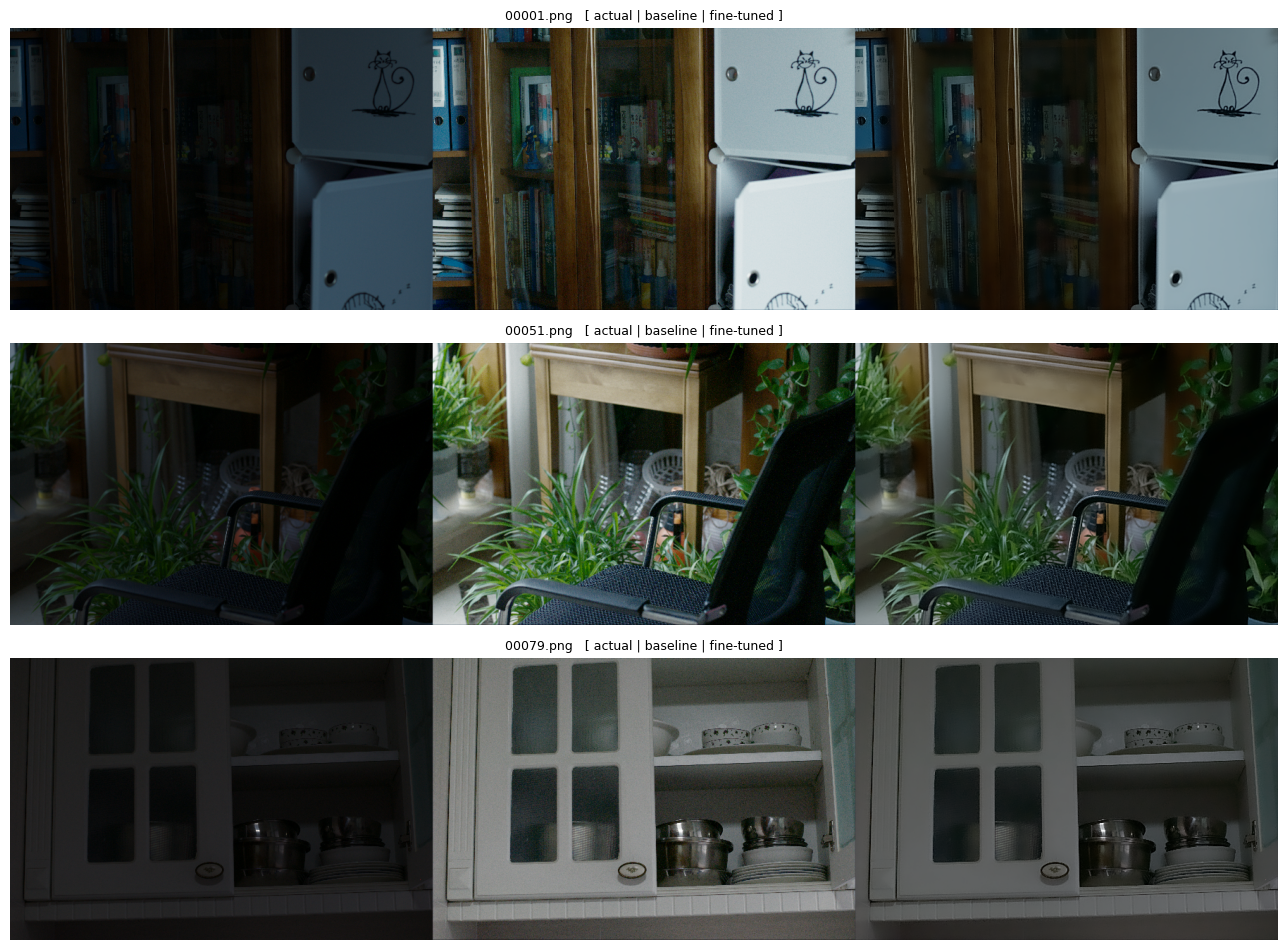

In [18]:
df = ab_test(baseline_weights=BASE_W, modified_weights=NB_FT_W.replace('.pt', '_best.pt'),data=FT_DATA, denoise=DENOISE, denoise_radius=DENOISE_RADIUS, denoise_eps=DENOISE_EPS, gamma=GAMMA, highlight=HIGHLIGHT, sharpen=SHARPEN)
display(df)
show_ab(df)

---
## Notes
* **Everything we produce lives in `./Experiment/`** — `nb_trained.pt` / `nb_trained_best.pt`,
  `nb_finetuned.pt` / `nb_finetuned_best.pt`, and the `*_best_selection.png` graphs.
* **Why the best model:** `plot_selection` shows the validation **structure-F1 per epoch** with
  the chosen epoch starred — we keep the F1 peak (loss is shown only for context; it does *not*
  drive selection, since SCI++'s alternating two-loss is a weak quality proxy).
* **Optimise quickly:** re-invoke with new values, e.g. `finetune(noise_weight=0.4, steps=20)`
  then `show_ab(ab_test())`. Point `val_data` at a held-out folder for a true validation score.